# **EfficientNet Pre-trained Binary Model with Raw Input**

In this notebook we test a pre-trained EfficientNet model to predict Animal vs Non-animal. For this, the original images were used.

## Libraries

In [1]:
# Libraries
import pandas as pd

from deep.constants import ROOT, METADATA_FILE, SEEDS, SCORES
from deep.modelling.model_runs import run_binary_model
from deep.modelling.model_specifications import efficient_net

2025-04-27 18:49:55.289566: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-27 18:49:55.290261: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-27 18:49:55.293708: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-27 18:49:55.302910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745776195.319403    9996 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745776195.32

In [2]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [3]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing and Modelling

In [4]:
# Define path
binary_baseline_path = SCORES / "binary_scores.json"

### Resize Images

In [5]:
# notebook_path = f'"{ROOT}/notebooks/preprocess_routine/resize_routine.ipynb"'
# %run $notebook_path

### Raw Model

In this section we test which loss function yelds the best results

#### Binary CrossEntropy

2025-04-27 18:49:57.637504: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


No baseline score found, saving current as baseline after run.
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


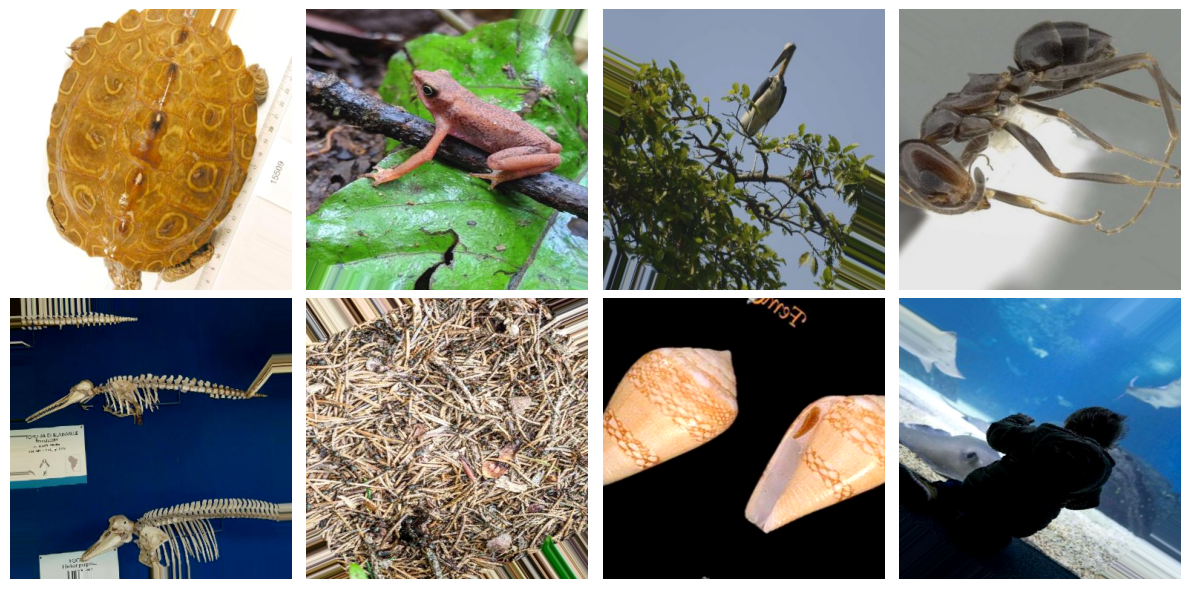

/home/nottoriousgg/miniconda3/envs/deep/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


128/128 ━━━━━━━━━━━━━━━━━━━━ 966s 7s/step - accuracy: 0.8143 - auc: 0.5200 - loss: 0.5404 - precision: 0.9279 - recall: 0.8661 - val_accuracy: 0.9291 - val_auc: 0.5016 - val_loss: 0.2569 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Train Loss: 0.4240531623363495
Validation Loss: 0.25689756870269775
Train Precision:0.9299167394638062
Validation Precision: 0.9291174411773682


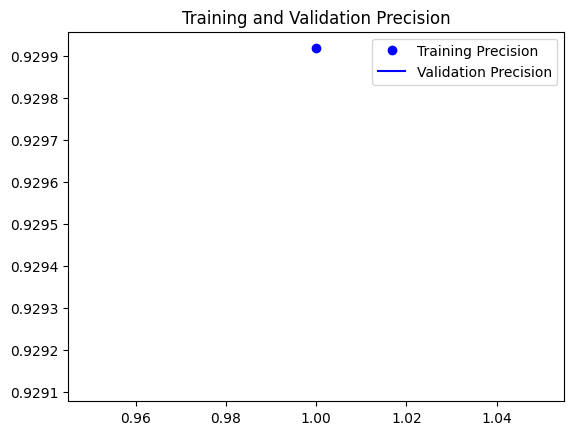

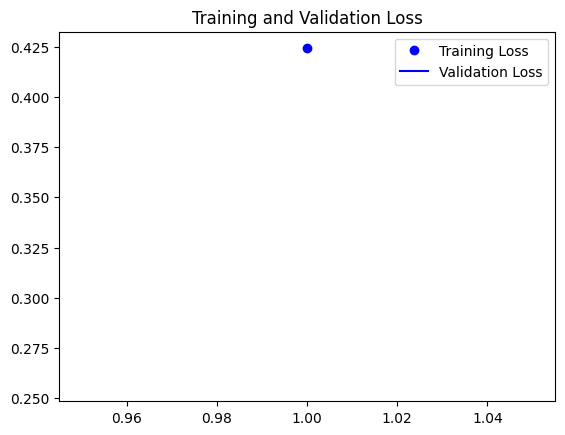

TypeError: Object of type type is not JSON serializable

In [6]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=1
    ,is_upsample=False
    ,model_name='efficientnetb4'
)

#### Focal Loss

In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='focal'
    ,epochs=10
    ,type='original'
)

The binary crossentropy loss function performed better and so this is the loss function we will be using from now on.

### Model with Regularization

In this section we add L2 regularization to our model and test if it improves the model

In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=True
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
)

Regularization did not improve the model.

### Model with Dropout

In this section we add a dropout layer to the model and test if it improves the results.

In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=True
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
)

The dropout layer did not improve the model.

Now, we will attempt to transform the input images and recheck the model.